In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
url="/content/drive/MyDrive/dataset/weatherAUS.csv"

In [ ]:
df=pd.read_csv(url)

In [ ]:
df.head(1)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No


In [ ]:
df.shape

(145460, 23)

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


In [ ]:
df['Date'].value_counts()

,count
Date,
2017-06-24,49
2017-06-23,49
2017-06-22,49
2017-06-21,49
2017-06-20,49
...,...
2008-01-27,1
2008-01-28,1
2008-01-29,1


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
df['year'] = df['Date'].dt.year

In [ ]:
df["year"].unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2007],
      dtype=int32)

In [ ]:
df['month_no.'] = df['Date'].dt.month

In [ ]:
df['month_no.'].unique()

array([12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=int32)

In [ ]:
df['day'] = df['Date'].dt.day

In [ ]:
df.head(1)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,year,month_no.,day
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,1007.1,8.0,NaN,16.9,21.8,No,No,2008,12,1


<Axes: ylabel='count'>

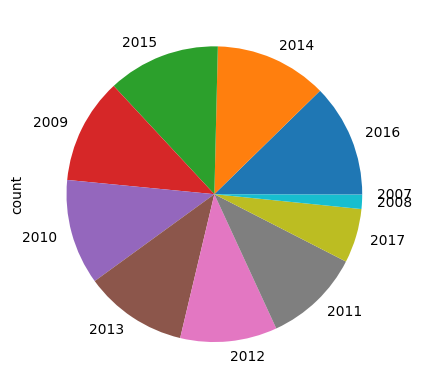

In [ ]:
df['year'].value_counts().plot(kind='pie')

<Axes: ylabel='count'>

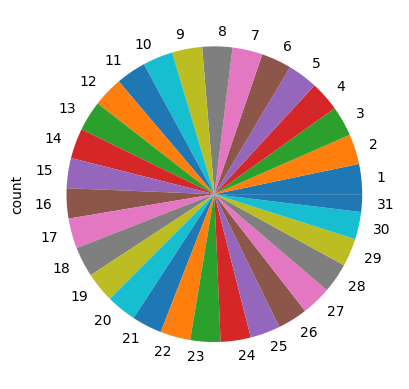

In [ ]:
df['day'].value_counts().plot(kind='pie')

In [ ]:
df['Date'].nunique()

3436

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


In [ ]:
df.head(2)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,year,month_no.,day
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,1007.1,8.0,NaN,16.9,21.8,No,No,2008,12,1
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,1007.8,NaN,NaN,17.2,24.3,No,No,2008,12,2


In [ ]:
df.shape

(145460, 26)

In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

In [ ]:
cols_to_drop = missing_percent[missing_percent > 30].index

In [ ]:
cols_to_drop

Index(['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'], dtype='object')

In [ ]:
df.drop(cols_to_drop, axis=1, inplace=True)

In [ ]:
df.shape

(145460, 22)

In [ ]:
df.drop('Date', axis=1, inplace=True)

In [ ]:
df.drop('WindGustDir', axis=1, inplace=True)

In [ ]:
df.isnull().sum()

,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566
WindDir3pm,4228
WindSpeed9am,1767
WindSpeed3pm,3062


##handleing missing value

###Handle Numerical Missing Values

In [ ]:
num_cols = df.select_dtypes(include=['float64','int64']).columns

In [ ]:
for col in num_cols:
    df[col] = df.groupby('Location')[col].transform(
        lambda x: x.fillna(x.median())
    )

###Handle Categorical Missing Values

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df.groupby('Location')[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
    )

In [ ]:
df.dropna(subset=['Pressure9am','Pressure3pm'], inplace=True)

In [ ]:
cols = ['WindGustSpeed']

for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-1016/847360954.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df.isnull().sum()

,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
WindGustSpeed,0
WindDir9am,0
WindDir3pm,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0


##normalization and one hot encoding

In [ ]:

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [ ]:
cat_cols

Index(['Location', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow'], dtype='object')

In [ ]:
df.shape

(133341, 20)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Define X and y
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

# Redefine num_cols and cat_cols based on X (features only)
num_cols_X = X.select_dtypes(include=['int64','float64']).columns
cat_cols_X = X.select_dtypes(include=['object']).columns

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Encode target variable
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# Create transformer
a = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_X),
        ('cat', OneHotEncoder(drop='first'), cat_cols_X)
    ])

# Fit ONLY on training data
X_train_processed = a.fit_transform(X_train)

# Transform test data
X_test_processed = a.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression(max_iter=1000)
model.fit(X_train_processed, y_train)
y_pred = model.predict(X_test_processed)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8442011324009149


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)

accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.7886684915069931


In [ ]:
from sklearn.svm import SVC
model = SVC()
model.fit(X_train_processed, y_train)
y_pred = model.predict(X_test_processed)
accuracy = accuracy_score(y_test, y_pred)
print("SVM Accuracy:", accuracy)

SVM Accuracy: 0.8533503318459634


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_processed, y_train)
y_pred = model.predict(X_test_processed)
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.8489257189995876


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [ ]:
pip install xgboost

In [ ]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [91]:
model.fit(X_train_processed, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:06:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [90]:
y_pred = model.predict(X_test_processed)

In [92]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8530128613746297


In [93]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[19553  1019]
 [ 2901  3196]]


In [94]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [95]:
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [96]:
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [97]:
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [98]:
grid.fit(X_train_processed, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:25:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, 8],
                         'n_estimators': [200, 400], 'subsample': [0.8, 1]},
             scoring='accuracy', verbose=1)

In [100]:
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'subsample': 0.8}
Best CV Accuracy: 0.8612850756623539


In [101]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_processed)

from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.8555251415501144


In [102]:
!pip install nbformat